In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np



In [ ]:
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader

class DarkMatterDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.file_paths = []
        self.labels = []

        self.classes = ['axion', 'cdm', 'no_sub']

        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            files = glob.glob(os.path.join(cls_dir, '*.npy'))
            for f in files:
                self.file_paths.append((f, cls))

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path, cls_name = self.file_paths[idx]

        # Load numpy array
        data = np.load(file_path, allow_pickle=True)
        if cls_name == 'axion':
            img = data[0]
        else:
            img = data

        img = img.astype(np.float32)
        tensor_img = torch.from_numpy(img)

        tensor_img = tensor_img.unsqueeze(0)

        if self.transform:
            tensor_img = self.transform(tensor_img)

        return tensor_img, cls_name

root_path = '/content/drive/My Drive/Dataset_MAE'
dataset = DarkMatterDataset(root_dir=root_path)
print(f"Total samples found: {len(dataset)}")

if len(dataset) > 0:
    sample_img, sample_cls = dataset[0]
    print(f"Sample class: {sample_cls}")
    print(f"Sample tensor shape: {sample_img.shape}")


Total samples found: 89104
Sample class: axion
Sample tensor shape: torch.Size([1, 64, 64])


In [ ]:
import torch
from torch.utils.data import DataLoader, Subset

no_sub_indices = [i for i, (_, cls_name) in enumerate(dataset.file_paths) if cls_name == 'no_sub']
no_sub_dataset = Subset(dataset, no_sub_indices)
batch_size = 64
pretrain_loader = DataLoader(no_sub_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"Pre-training dataset size (no_sub only): {len(no_sub_dataset)} samples")
print(f"Pre-training DataLoader batches: {len(pretrain_loader)}")

Pre-training dataset size (no_sub only): 29449 samples
Pre-training DataLoader batches: 461


In [ ]:
import torch
import torch.nn as nn

class PatchEmbed(nn.Module):
    """Split image into patches and embed them."""
    def __init__(self, img_size=64, patch_size=8, in_chans=1, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W) -> (B, EmbedDim, H/P, W/P) -> (B, EmbedDim, NumPatches) -> (B, NumPatches, EmbedDim)
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

class MaskedAutoencoder(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_chans=1,
                 embed_dim=128, depth=4, num_heads=4,
                 decoder_embed_dim=64, decoder_depth=2, decoder_num_heads=2):
        super().__init__()

        # MAE Encoder specifics
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        # MAE Decoder specifics
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim))

        decoder_layer = nn.TransformerEncoderLayer(d_model=decoder_embed_dim, nhead=decoder_num_heads, batch_first=True)
        self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=decoder_depth)

        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans)

    def random_masking(self, x, mask_ratio):
        N, L, D = x.shape  # batch, length, dim
        len_keep = int(L * (1 - mask_ratio))

        noise = torch.rand(N, L, device=x.device)  # noise in [0, 1]

        ids_shuffle = torch.argsort(noise, dim=1)  # ascend: small is keep, large is remove
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # keep the first subset
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

        # generate the binary mask: 0 is keep, 1 is remove
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore

    def forward_encoder(self, x, mask_ratio):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        x, mask, ids_restore = self.random_masking(x, mask_ratio)

        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.encoder(x)
        return x, mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x.shape[2]))
        x = torch.cat([x[:, :1, :], x_], dim=1)

        x = x + self.decoder_pos_embed
        x = self.decoder(x)
        x = self.decoder_pred(x)
        x = x[:, 1:, :]
        return x

    def forward(self, imgs, mask_ratio=0.75):
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        return pred, mask

model = MaskedAutoencoder(img_size=64, patch_size=8, in_chans=1)
dummy_img = torch.randn(2, 1, 64, 64)
pred, mask = model(dummy_img, mask_ratio=0.75)

print(f"Output predictions shape: {pred.shape}")
print(f"Mask shape: {mask.shape}")


Output predictions shape: torch.Size([2, 64, 64])
Mask shape: torch.Size([2, 64])


In [ ]:
import torch
from torch.utils.data import DataLoader, random_split

dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
dataloaders = {
    'train': train_loader,
    'val': val_loader
}

save_path = '/content/drive/My Drive/Dataset_MAE/dataloaders.pth'
torch.save(dataloaders, save_path)

print(f"DataLoaders successfully saved to {save_path}")
print(f"Train set size: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"Validation set size: {len(val_dataset)} samples ({len(val_loader)} batches)")

DataLoaders successfully saved to /content/drive/My Drive/Dataset_MAE/dataloaders.pth
Train set size: 71283 samples (1114 batches)
Validation set size: 17821 samples (279 batches)


In [ ]:
import torch.optim as optim
from tqdm import tqdm

def pretrain_mae(model, dataloader, epochs=5, lr=1e-4, device='cuda'):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)

    # MSE loss for reconstruction
    criterion = nn.MSELoss(reduction='none')

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        loop = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch in loop:
            imgs, _ = batch
            imgs = imgs.to(device)

            optimizer.zero_grad()

            # Forward pass: imgs shape [B, 1, 64, 64]
            pred, mask = model(imgs)

            # Original image: [B, C, H, W] -> patches: [B, NumPatches, PatchArea]
            patch_size = model.patch_embed.patch_size
            B, C, H, W = imgs.shape
            target = imgs.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
            target = target.contiguous().view(B, C, -1, patch_size, patch_size)
            target = target.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, patch_size**2 * C)

            # Calculate loss only on masked patches
            loss = criterion(pred, target)
            loss = (loss.mean(dim=-1) * mask).sum() / mask.sum()

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(dataloader)
        print(f'Epoch {epoch+1} Average Loss: {avg_loss:.4f}')

    return model

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Run pre-training
pretrained_model = pretrain_mae(model, pretrain_loader, epochs=50, device=device)

# Save the pre-trained weights
torch.save(pretrained_model.state_dict(), '/content/drive/My Drive/Dataset_MAE/mae_pretrained.pth')
print("Pre-trained model saved!")


Using device: cuda


Epoch 1/50:   1%|          | 4/461 [02:36<4:57:16, 39.03s/it, loss=0.29]


KeyboardInterrupt: 

In [ ]:
# Download the dataset directly to Colab's fast local storage
!pip install -q gdown
!gdown --id 1znqUeFzYz-DeAE3dYXD17qoMPK82Whji -O /content/dataset.zip

print("Extracting dataset to local storage... This might take a minute.")
!unzip -q /content/dataset.zip -d /content/local_dataset
print("Extraction complete!")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji
From (redirected): https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji&confirm=t&uuid=9501c2ae-4315-4a2b-8130-f9f1abc0783c
To: /content/dataset.zip
100% 2.89G/2.89G [02:09<00:00, 22.2MB/s]
Extracting dataset to local storage... This might take a minute.
Extraction complete!


In [ ]:
import os
import glob
import torch
from torch.utils.data import DataLoader, Subset, random_split

axion_dirs = glob.glob('/content/local_dataset/**/axion', recursive=True)
local_root_path = os.path.dirname(axion_dirs[0])
print(f"Local dataset root path: {local_root_path}")
dataset = DarkMatterDataset(root_dir=local_root_path)
print(f"Total samples found locally: {len(dataset)}")

no_sub_indices = [i for i, (_, cls_name) in enumerate(dataset.file_paths) if cls_name == 'no_sub']
no_sub_dataset = Subset(dataset, no_sub_indices)

batch_size = 64
# Increased num_workers to 4 and added pin_memory=True for much faster GPU transfers
pretrain_loader = DataLoader(no_sub_dataset, batch_size=batch_size, shuffle=True,
                             num_workers=4, pin_memory=True)

# 3. Re-create train and val dataloaders for fine-tuning later
dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=4, pin_memory=True)

dataloaders = {
    'train': train_loader,
    'val': val_loader
}

print("All DataLoaders updated to use fast local storage! You can now re-run the training cells.")

Local dataset root path: /content/local_dataset/Dataset
Total samples found locally: 89104
All DataLoaders updated to use fast local storage! You can now re-run the training cells.


In [ ]:
import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn

def pretrain_mae(model, dataloader, epochs=5, lr=1e-4, device='cuda'):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    criterion = nn.MSELoss(reduction='none')
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        loop = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch in loop:
            imgs, _ = batch
            imgs = imgs.to(device)
            optimizer.zero_grad()
            pred, mask = model(imgs)
            patch_size = model.patch_embed.patch_size
            B, C, H, W = imgs.shape
            target = imgs.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
            target = target.contiguous().view(B, C, -1, patch_size, patch_size)
            target = target.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, patch_size**2 * C)
            loss = criterion(pred, target)
            loss = (loss.mean(dim=-1) * mask).sum() / mask.sum()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(dataloader)
        print(f'Epoch {epoch+1} Average Loss: {avg_loss:.4f}')
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
pretrained_model = pretrain_mae(model, pretrain_loader, epochs=50, device=device)
torch.save(pretrained_model.state_dict(), '/content/drive/My Drive/Dataset_MAE/mae_pretrained.pth')
print("Pre-trained model saved!")


Using device: cuda


Epoch 1/50: 100%|██████████| 461/461 [00:09<00:00, 46.95it/s, loss=0.00863]


Epoch 1 Average Loss: 0.0119


Epoch 2/50: 100%|██████████| 461/461 [00:09<00:00, 47.14it/s, loss=0.00823]


Epoch 2 Average Loss: 0.0093


...

Epoch 48 Average Loss: 0.0016


Epoch 49/50: 100%|██████████| 461/461 [00:09<00:00, 46.12it/s, loss=0.000981]


Epoch 49 Average Loss: 0.0016


Epoch 50/50: 100%|██████████| 461/461 [00:09<00:00, 47.04it/s, loss=0.0013]


Epoch 50 Average Loss: 0.0015
Pre-trained model saved!


Fine-tune Epoch 1/50: 100%|██████████| 1114/1114 [00:17<00:00, 63.50it/s, loss=0.347]


Epoch 1 Loss: 0.3537


Fine-tune Epoch 2/50: 100%|██████████| 1114/1114 [00:17<00:00, 65.22it/s, loss=0.285]


Epoch 2 Loss: 0.3172


Fine-tune Epoch 3/50: 100%|██████████| 1114/1114 [00:16<00:00, 66.50it/s, loss=0.253]


...

Epoch 48 Loss: 0.1314


Fine-tune Epoch 49/50: 100%|██████████| 1114/1114 [00:17<00:00, 64.98it/s, loss=0.054]


Epoch 49 Loss: 0.1308


Fine-tune Epoch 50/50: 100%|██████████| 1114/1114 [00:17<00:00, 64.97it/s, loss=0.337]

Epoch 50 Loss: 0.1347


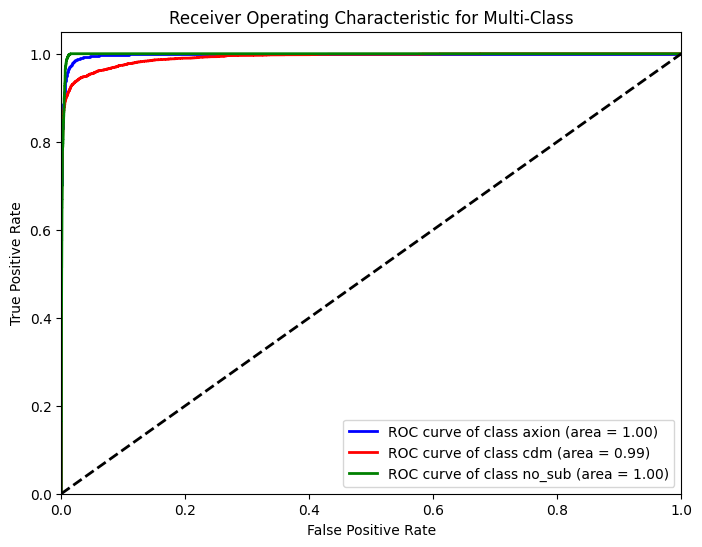

AUC Scores:
axion: 0.9980
cdm: 0.9915
no_sub: 0.9984


In [ ]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np
from tqdm import tqdm

class ViTClassifier(nn.Module):
    def __init__(self, mae_model, embed_dim=128, num_classes=3):
        super().__init__()
        self.encoder = mae_model
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # Pass through patch embedding
        x = self.encoder.patch_embed(x)
        x = x + self.encoder.pos_embed[:, 1:, :]

        # Append cls token
        cls_token = self.encoder.cls_token + self.encoder.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        # Apply Transformer encoder
        x = self.encoder.encoder(x)

        # Extract cls token output
        cls_out = x[:, 0, :]
        return self.head(cls_out)

classifier = ViTClassifier(model).to(device)

# 2. Fine-tuning Setup
label_map = {'axion': 0, 'cdm': 1, 'no_sub': 2}
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=0.05)

def train_classifier(model, train_loader, epochs=3):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        loop = tqdm(train_loader, desc=f'Fine-tune Epoch {epoch+1}/{epochs}')
        for imgs, labels in loop:
            imgs = imgs.to(device)
            targets = torch.tensor([label_map[l] for l in labels]).to(device)

            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

# Run fine-tuning
train_classifier(classifier, dataloaders['train'], epochs=50)

# 3. Evaluation Setup (ROC and AUC)
def evaluate_model(model, val_loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            targets = torch.tensor([label_map[l] for l in labels]).numpy()

            preds = torch.softmax(model(imgs), dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(targets)

    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    # Binarize labels for multi-class ROC
    y_test = label_binarize(all_targets, classes=[0, 1, 2])
    n_classes = y_test.shape[1]

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    classes_names = ['axion', 'cdm', 'no_sub']

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], all_preds[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'red', 'green']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve of class {classes_names[i]} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for Multi-Class')
    plt.legend(loc="lower right")
    plt.show()

    print("AUC Scores:")
    for i in range(n_classes):
        print(f"{classes_names[i]}: {roc_auc[i]:.4f}")

# Evaluate the fine-tuned model
evaluate_model(classifier, dataloaders['val'])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

def pretrain_mae(model, dataloader, epochs=5, lr=1e-4, device='cuda'):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    criterion = nn.MSELoss(reduction='none')

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        loop = tqdm(dataloader, desc=f'Pre-train Epoch {epoch+1}/{epochs}')
        for batch in loop:
            imgs, _ = batch
            imgs = imgs.to(device)

            optimizer.zero_grad()
            pred, mask = model(imgs)

            # Flatten target to match prediction
            patch_size = model.patch_embed.patch_size
            B, C, H, W = imgs.shape
            target = imgs.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
            target = target.contiguous().view(B, C, -1, patch_size, patch_size)
            target = target.permute(0, 2, 3, 4, 1).contiguous().view(B, -1, patch_size**2 * C)

            loss = criterion(pred, target)
            loss = (loss.mean(dim=-1) * mask).sum() / mask.sum()

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(dataloader)
        print(f'Epoch {epoch+1} Average Loss: {avg_loss:.4f}')
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Run pre-training (Epochs set to 3 for demonstration; increase for better results)
pretrained_model = pretrain_mae(model, pretrain_loader, epochs=50, device=device)
torch.save(pretrained_model.state_dict(), '/content/drive/My Drive/Dataset_MAE/mae_pretrained.pth')
print("Pre-trained MAE model saved!")

Using device: cuda


Pre-train Epoch 1/50:   0%|          | 0/461 [00:00<?, ?it/s]

Epoch 1 Average Loss: 0.0114


Pre-train Epoch 2/50:   0%|          | 0/461 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dff719585e0><function _MultiProcessingDataLoaderIter.__del__ at 0x7dff719585e0><function _MultiProcessingDataLoaderIter.__del__ at 0x7dff719585e0>

Traceback (most recent call last):
Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7dff719585e0>
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()self._shutdown_workers()

      File "/usr/local/lib/

...

Pre-train Epoch 12/50:   0%|          | 0/461 [00:00<?, ?it/s]

Epoch 12 Average Loss: 0.0017


Pre-train Epoch 13/50:   0%|          | 0/461 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dff719585e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^Exception ignored in: ^
<function _MultiProcessingDataLoaderIter.__del__ at 0x7dff719585e0>  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

    Traceback (most recent call last):
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

      self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
        ^ ^ ^ ^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Define Classifier using the Pre-trained MAE Encoder
class MAEClassifier(nn.Module):
    def __init__(self, mae_model, embed_dim=128, num_classes=3):
        super().__init__()
        self.encoder = mae_model
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.encoder.patch_embed(x)
        x = x + self.encoder.pos_embed[:, 1:, :]

        cls_token = self.encoder.cls_token + self.encoder.pos_embed[:, :1, :]
        cls_tokens = cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = self.encoder.encoder(x)
        cls_out = x[:, 0, :] # Extract CLS token
        return self.head(cls_out)

classifier = MAEClassifier(pretrained_model).to(device)

# 2. Fine-tuning
label_map = {'axion': 0, 'cdm': 1, 'no_sub': 2}
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=0.05)

def train_classifier(model, train_loader, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        loop = tqdm(train_loader, desc=f'Fine-tune Epoch {epoch+1}/{epochs}')
        for imgs, labels in loop:
            imgs = imgs.to(device)
            targets = torch.tensor([label_map[l] for l in labels]).to(device)

            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

train_classifier(classifier, dataloaders['train'], epochs=5)

# 3. Evaluation Setup (ROC and AUC)
def evaluate_model(model, val_loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            targets = np.array([label_map[l] for l in labels])

            preds = torch.softmax(model(imgs), dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(targets)

    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    y_test = label_binarize(all_targets, classes=[0, 1, 2])
    n_classes = y_test.shape[1]

    fpr, tpr, roc_auc = dict(), dict(), dict()
    classes_names = ['axion', 'cdm', 'no_sub']

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], all_preds[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    colors = ['blue', 'red', 'green']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC {classes_names[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

    for i in range(n_classes):
        print(f"{classes_names[i]} AUC: {roc_auc[i]:.4f}")

evaluate_model(classifier, dataloaders['val'])